In [265]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [266]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [267]:
modeApi = lumapi.MODE(hide = False)

#units

um = 1e-6
nm = 1e-9

## Especificação das dimensões do guia e materiais ##

In [268]:
# Dimensions
gap = 200*nm
wvg_width = 0.45*um
wvg_height = 0.22*um
rad = 10*um
Lc = 5*um

# Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

## Criação dos objetos do dispositivo ##

In [269]:
modeApi.addrect()
modeApi.set('name', 'core_1')
modeApi.set('x', 0)
modeApi.set('x span', Lc)
modeApi.set('y', (gap+wvg_width)/2)
modeApi.set('y span', wvg_width)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

modeApi.addobject('90_bend_wg')
modeApi.set('name', '90_bend_1')
modeApi.set('radius', rad)
modeApi.set('base height', wvg_height)
modeApi.set('base width', wvg_width)
modeApi.set('x', Lc/2)
modeApi.set('y', rad+(gap+wvg_width)/2)
modeApi.set('z', 0)
modeApi.set('first axis', 'x')
modeApi.set('rotation 1', 180)
modeApi.set('material', material)

modeApi.addobject('90_bend_wg')
modeApi.set('name', '90_bend_2')
modeApi.set('radius', rad)
modeApi.set('base height', wvg_height)
modeApi.set('base width', wvg_width)
modeApi.set('x', -Lc/2)
modeApi.set('y', rad+(gap+wvg_width)/2)
modeApi.set('z', 0)
modeApi.set('first axis', 'x')
modeApi.set('second axis', 'y')
modeApi.set('rotation 1', 180)
modeApi.set('rotation 2', 180)
modeApi.set('material', material)

modeApi.addrect()
modeApi.set('name', 'core_2')
modeApi.set('x', 0)
modeApi.set('x span', Lc + 2*rad)
modeApi.set('y', -(gap+wvg_width)/2)
modeApi.set('y span', wvg_width)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

## Definindo o solver FDE ##

In [249]:
x_fde = 0
y_fde = 0
x_span_fde = 0
y_span_fde = 4*um
z_span_fde = 4*um
z_fde = 0
mesh_cells = 100
wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
modes = 4
mesh_multiplier = 5

In [250]:
# Add solver
modeApi.addfde()
modeApi.set('solver type', '2D X normal')
modeApi.set('background material', sub_material)
modeApi.set('x', x_fde)
#modeApi.set('x span', x_span_fde)
modeApi.set('y', y_fde)
modeApi.set('y span', y_span_fde)
modeApi.set('z', z_fde)
modeApi.set('z span', z_span_fde)
modeApi.set('define y mesh by', 'number of mesh cells')
modeApi.set('define z mesh by', 'number of mesh cells')
modeApi.set('mesh cells y', mesh_cells)
modeApi.set('mesh cells z', mesh_cells)

modeApi.set('wavelength', wavelength)
modeApi.set('number of trial modes', modes)

modeApi.set('fit materials with multi-coefficient model', True)
modeApi.set('wavelength start', start_wavelength)
modeApi.set('wavelength stop', stop_wavelength)

modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')
modeApi.set('z min bc', 'PML')
modeApi.set('z max bc', 'PML')

#add mesh
modeApi.addmesh()
modeApi.set('set mesh multiplier', True)
modeApi.set('x', x_fde)
modeApi.set('x span', 0)
modeApi.set('x mesh multiplier', 1)
modeApi.set('y', y_fde)
modeApi.set('y span', 0.35*y_span_fde)
modeApi.set('y mesh multiplier', mesh_multiplier)
modeApi.set('z', z_fde)
modeApi.set('z span', 0.35*z_span_fde)
modeApi.set('z mesh multiplier', mesh_multiplier)

# Determinação dos modos propagantes ##

In [251]:
number_of_modes = int(modeApi.findmodes())
print(number_of_modes)

4


In [252]:
eField = np.squeeze(modeApi.getresult('FDE::data::mode1', 'Ey'))
y_eField = modeApi.getresult('FDE::data::mode1', 'y')/um
z_eField = modeApi.getresult('FDE::data::mode1', 'z')/um
n1 = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]

rfIndex = np.squeeze(modeApi.getresult('FDE::data::material', 'index_y'))
print(n1)

2.371327351334061


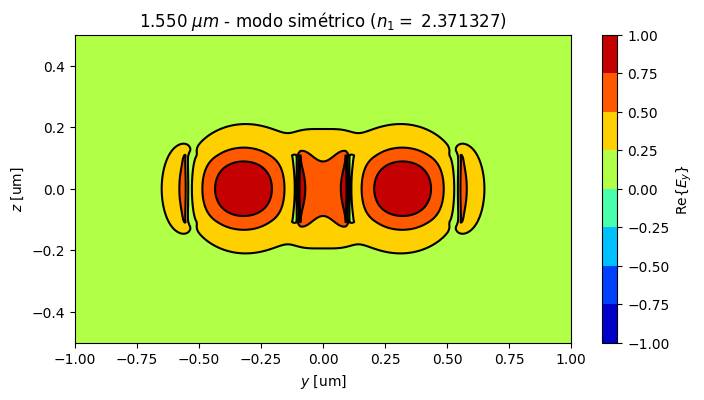

In [253]:
v = np.linspace(-1, 1, 9)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
Y, Z = np.meshgrid(y_eField, z_eField)
plt.contourf(Y, Z, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(Y, Z, np.rot90(eField.real), v, colors = 'k', vmin = -1, vmax = 1)
im = plt.contourf(Y, Z, np.rot90(eField.real), v, cmap = plt.cm.jet, vmin = -1, vmax = 1)

colorbar = plt.colorbar(im)
colorbar.set_ticks(v)
colorbar.set_label(r'$\mathrm{Re}\{E_y\}$')

plt.xlabel(r'$y$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$z$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'%4.3f $\mu m$ - modo simétrico ($n_1 =$ %.6f)' %(wavelength/um, n1))
plt.show()

In [254]:
eField = np.squeeze(modeApi.getresult('FDE::data::mode2', 'Ey'))
y_eField = modeApi.getresult('FDE::data::mode2', 'y')/um
z_eField = modeApi.getresult('FDE::data::mode2', 'z')/um
n2 = (modeApi.getresult('FDE::data::mode2', 'neff').real)[0,0]

print(n2)

2.3392800133113543


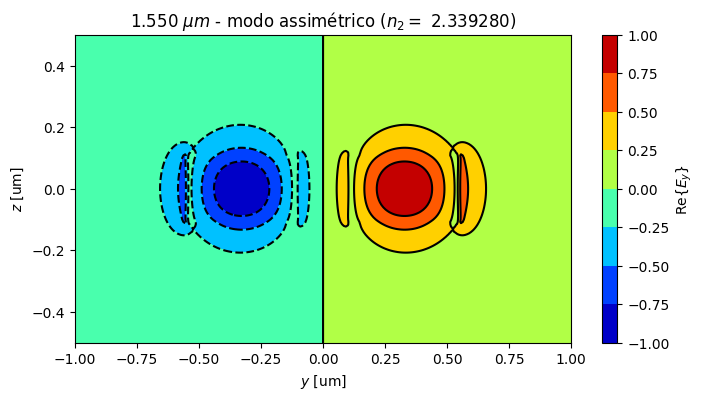

In [255]:
v = np.linspace(-1, 1, 9)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
Y, Z = np.meshgrid(y_eField, z_eField)
plt.contourf(Y, Z, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(Y, Z, np.rot90(eField.real), v, colors = 'k', vmin = -1, vmax = 1)
im = plt.contourf(Y, Z, np.rot90(eField.real), v, cmap = plt.cm.jet, vmin = -1, vmax = 1)

colorbar = plt.colorbar(im)
colorbar.set_ticks(v)
colorbar.set_label(r'$\mathrm{Re}\{E_y\}$')

plt.xlabel(r'$y$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$z$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'%4.3f $\mu m$ - modo assimétrico ($n_2 =$ %.6f)' %(wavelength/um, n2))
plt.show()

In [256]:
Delta_n = abs(n1 - n2)
print('\u0394n = %.6f' %Delta_n)

Δn = 0.032047


## Análise de convergência  considerando a precisão do mesh ##

In [257]:
modeApi.switchtolayout()
modeApi.select('mesh')
modeApi.set('enabled', 0)

mesh_cells_array = np.arange(20,210,10)
Delta_n_array = []

for m in mesh_cells_array:
    modeApi.select('FDE')
    modeApi.set('mesh cells y', m)
    modeApi.set('mesh cells z', m)
    modeApi.findmodes()
    n1_m = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]
    n2_m = (modeApi.getresult('FDE::data::mode2', 'neff').real)[0,0]
    Delta_n_array.append(abs(n1_m - n2_m))
    modeApi.switchtolayout()

modeApi.select('mesh')
modeApi.set('enabled', 1)
modeApi.select('FDE')
modeApi.set('mesh cells y', mesh_cells)
modeApi.set('mesh cells z', mesh_cells)

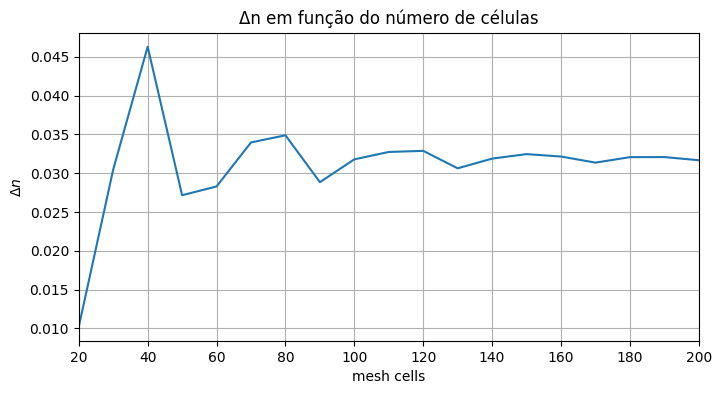

In [258]:
plt.figure(figsize=(8, 4))
plt.plot(mesh_cells_array, Delta_n_array)
plt.xlabel('mesh cells')
plt.ylabel(r'$\Delta n$')
plt.title('\u0394n em função do número de células')
plt.xlim(20,200)
plt.grid(True)
plt.show()

## Comprimento de acoplamento em função da distância entre os guias ##

In [259]:
modeApi.switchtolayout()
modeApi.cleardcard()

In [260]:
gap_array = np.linspace(0,500,21) * nm
Delta_n_array_2 = np.zeros(len(gap_array))
for i in range (len(gap_array)):
    g = gap_array[i]
    modeApi.select('core_1')
    modeApi.set('y', (g+wvg_width)/2)
    modeApi.select('90_bend_1')
    modeApi.set('y', rad+(g+wvg_width)/2)
    modeApi.select('90_bend_2')
    modeApi.set('y', rad+(g+wvg_width)/2)
    modeApi.select('core_2')
    modeApi.set('y', -(g+wvg_width)/2)
    modeApi.findmodes()
    n1_g = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]
    n2_g = (modeApi.getresult('FDE::data::mode2', 'neff').real)[0,0]
    Delta_n_array_2[i] = abs(n1_g - n2_g)
    modeApi.switchtolayout()

modeApi.select('core_1')
modeApi.set('y', (gap+wvg_width)/2)
modeApi.select('90_bend_1')
modeApi.set('y', rad+(gap+wvg_width)/2)
modeApi.select('90_bend_2')
modeApi.set('y', rad+(gap+wvg_width)/2)
modeApi.select('core_2')
modeApi.set('y', -(gap+wvg_width)/2)

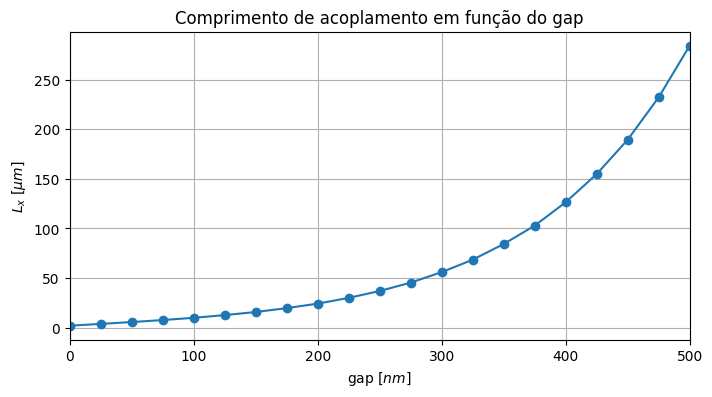

In [261]:
Lx_array = wavelength/(2*Delta_n_array_2)
fig = plt.figure(figsize=(8, 4))
plt.plot(gap_array/nm, Lx_array/um, 'o-')
plt.xlabel(r'gap $[nm]$')
plt.ylabel(r'$L_x$ ' + r'$[\mu m]$')
plt.xlim([gap_array[0]/nm, gap_array[-1]/nm])
plt.grid(True)
plt.title('Comprimento de acoplamento em função do gap')
plt.show()

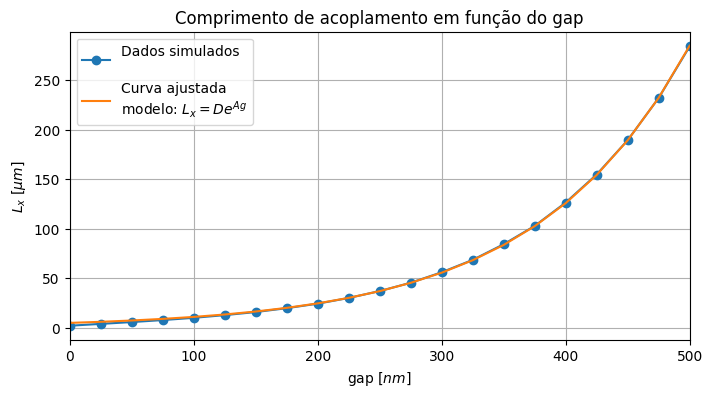

Parametros ajustados:
A = 0.008180/nm
B = 4.769250μm


In [262]:
from scipy.optimize import curve_fit

def f(x, A, D):
    return D * np.exp(A*x)

popt, pcov = curve_fit(f, gap_array, Lx_array)

def Lx_fit(x):
    return f(x, popt[0], popt[1])

fig = plt.figure(figsize=(8, 4))

# Plot the original data
plt.plot(gap_array/nm, Lx_array/um, 'o-', label = 'Dados simulados\n')

# Plot the fitted curve
plt.plot(gap_array/nm, Lx_fit(gap_array)/um, label = 'Curva ajustada\n' + r'modelo: $L_x = D e^{Ag}$')

plt.xlabel(r'gap $[nm]$')
plt.ylabel(r'$L_x$ ' + r'$[\mu m]$')
plt.xlim([gap_array[0]/nm, gap_array[-1]/nm])
plt.grid(True)
plt.title('Comprimento de acoplamento em função do gap')
plt.legend(loc = 'best')
plt.show()
print('\033[1mParametros ajustados:\nA = %.6f/nm\nB = %.6f\u03BCm\033[0m' %(popt[0]*nm, popt[1]/um))

## Acoplamento de potência em função do comprimento do dispositivo ##

In [263]:
C = np.pi*Delta_n / wavelength

def L(k2):
    k = np.sqrt(k2)
    CL = np.arcsin(k)
    L = CL/C
    return L

# 50/50

print('\033[1mComprimento do dispositivo para uma razão 50/50: %.6f\u03BCm' %(L(0.5)/um))

# 95/5

print('Comprimento do dispositivo para uma razão 95/5: %.6f\u03BCm' %(L(0.05)/um))

# 99/1

print('Comprimento do dispositivo para uma razão 99/1: %.6f\u03BCm\033[0m' %(L(0.01)/um))

Comprimento do dispositivo para uma razão 50/50: 12.091488μm
Comprimento do dispositivo para uma razão 95/5: 3.471860μm
Comprimento do dispositivo para uma razão 99/1: 1.542114μm
